 2.1 Veri Toplama

 Veriseti kaggle üzerinden bulunmuştur.
 Link:https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset?hl=en-EN




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('healthcare-dataset-stroke-data.csv')



2.2 Keşifsel Veri Analizi (EDA)

In [ ]:

df.drop('id', axis=1, inplace=True)

print("Veri Seti Boyutu (Satır, Sütun):", df.shape)

print("\nDeğişken Tipleri:\n", df.dtypes)

print("\nTemel İstatistiksel Özet:")
display(df.describe())

print("\nSütunlardaki Eksik Değer Sayıları:\n", df.isnull().sum())

print("\nHer Sütundaki Benzersiz (Unique) Değer Sayıları:\n", df.nunique())

print("\nSayısal Değişkenler Arası Korelasyon:")
display(df.select_dtypes(include=[np.number]).corr())

display(df.head())

Veri Seti Boyutu (Satır, Sütun): (5110, 11)

Değişken Tipleri:
 gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Temel İstatistiksel Özet:


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



Sütunlardaki Eksik Değer Sayıları:
 gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Her Sütundaki Benzersiz (Unique) Değer Sayıları:
 gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

Sayısal Değişkenler Arası Korelasyon:


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257
hypertension,0.276398,1.000000,0.108306,0.174474,0.167811,0.127904
heart_disease,0.263796,0.108306,1.000000,0.161857,0.041357,0.134914
avg_glucose_level,0.238171,0.174474,0.161857,1.000000,0.175502,0.131945
bmi,0.333398,0.167811,0.041357,0.175502,1.000000,0.042374
stroke,0.245257,0.127904,0.134914,0.131945,0.042374,1.000000


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


2.4 Aykırı Değer Analizi (IQR)

Yönergeye göre sırası ters ama önce aykırı değer daha sonra eksik değer analizi yapmak daha uygun--aykırı değerler eksik değerin yerini tutan değeri etkilememeli




In [ ]:

Q1 = df['avg_glucose_level'].quantile(0.25)
Q3 = df['avg_glucose_level'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print("Aykırı Değer Temizliği Öncesi Satır Sayısı:", df.shape[0])

df_temiz = df[(df['avg_glucose_level'] >= alt_sinir) & (df['avg_glucose_level'] <= ust_sinir)].copy()


print("Aykırı Değer Temizliği Sonrası Satır Sayısı:", df_temiz.shape[0])
print(f" {df.shape[0] - df_temiz.shape[0]} aykırı değer temizlendi.")


Aykırı Değer Temizliği Öncesi Satır Sayısı: 5110
Aykırı Değer Temizliği Sonrası Satır Sayısı: 4483
 627 aykırı değer temizlendi.


2.3 Eksik Değer Analizi ve Temizleme

In [ ]:

medyan_bmi = df_temiz['bmi'].median()

# NaN değerlerin yerine medyan- bmida aykırı değerler var ortalamadansa medyan daha uygun
df_temiz['bmi'] = df_temiz['bmi'].fillna(medyan_bmi)

# İşlemin başarılı olduğunu kontrol edelim
print("İşlem Sonrası Eksik Değer Sayıları:\n", df_temiz.isnull().sum())



İşlem Sonrası Eksik Değer Sayıları:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


2.5.1 Seaborn ile Görselleştirme

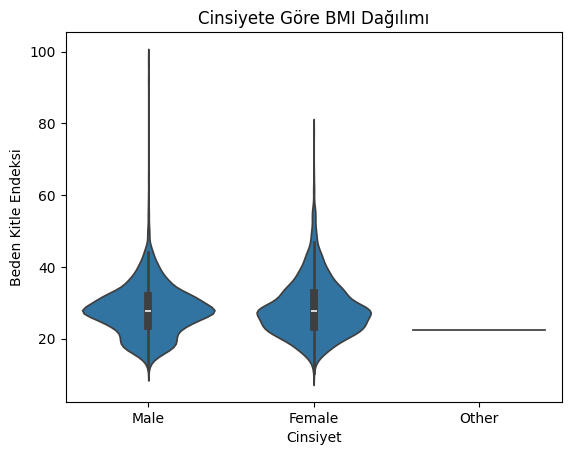

In [ ]:

# violinplot cinsitet bmi
#other kategorisinde tek bir hasta var, örüntü bulmak için yeterli bir veri değil, grafiklerde de kötü gözüküyor
sns.violinplot(data=df_temiz, x='gender', y='bmi')
plt.title('Cinsiyete Göre BMI Dağılımı')
plt.xlabel('Cinsiyet')
plt.ylabel('Beden Kitle Endeksi')
plt.show()

In [ ]:
display(df[df['gender'] == 'Other'])
#hasta da stroke geçirmemiş zaten, kaybetmemizin sorun olacağı bir veri değil

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


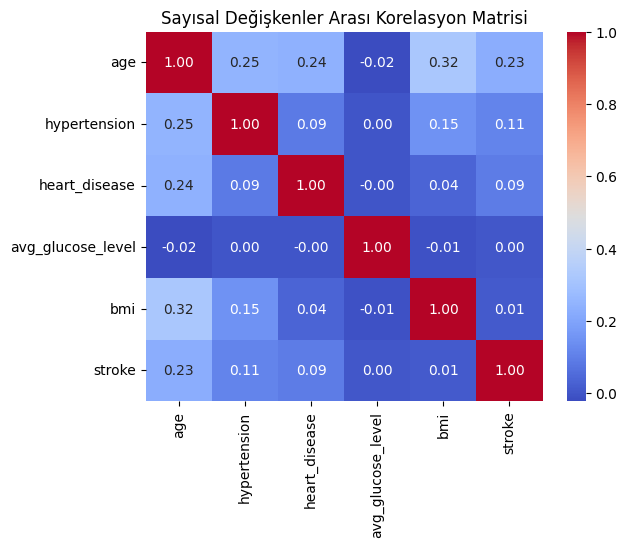

In [ ]:
#heatmap
sns.heatmap(df_temiz.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')
plt.show()

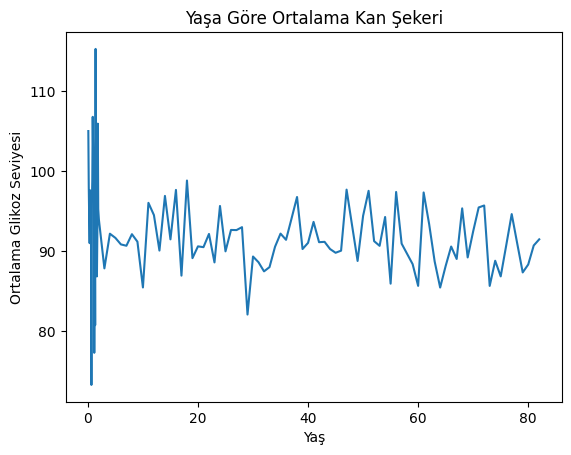

In [ ]:
#pediatrik hastalarda yaş arttıkça kan şekeri fizyolojik artar
#tip 2 dm ve kan şekeri patolojileri toplumda yaş arttıkça artar
#----------bizim veri setimizde neden artmadı??
#lineplot yaş- kan şekeri
sns.lineplot(data=df_temiz, x='age', y='avg_glucose_level',  errorbar=None)
plt.title('Yaşa Göre Ortalama Kan Şekeri')
plt.xlabel('Yaş')
plt.ylabel('Ortalama Glikoz Seviyesi')
plt.show()

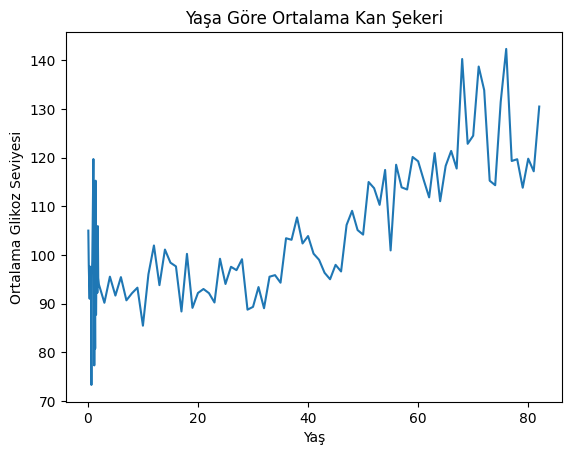

In [ ]:
#lineplot yaş- kan şekeri orijinal veri setinde
sns.lineplot(data=df, x='age', y='avg_glucose_level', errorbar=None)
plt.title('Yaşa Göre Ortalama Kan Şekeri')
plt.xlabel('Yaş')
plt.ylabel('Ortalama Glikoz Seviyesi')
plt.show()

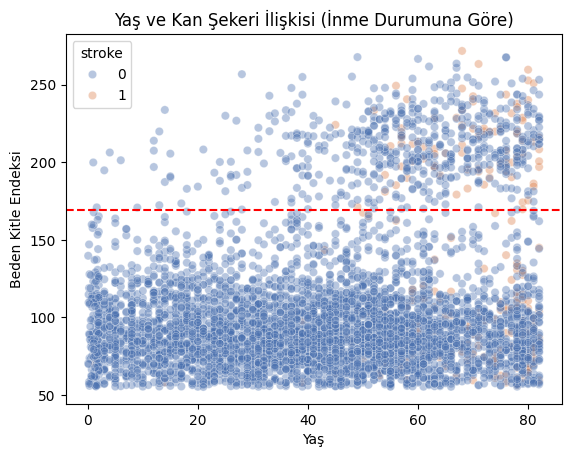

In [ ]:
# yaş- kan şekeri scatterplot
Q1_seker = df['avg_glucose_level'].quantile(0.25)
Q3_seker = df['avg_glucose_level'].quantile(0.75)
iqr_ust_sinir = Q3_seker + 1.5 * (Q3_seker - Q1_seker)
sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke', palette='deep', alpha=0.4)
plt.axhline(y=iqr_ust_sinir, color='red', linestyle='--',  label='IQR ust sınır')
plt.title('Yaş ve Kan Şekeri İlişkisi (İnme Durumuna Göre)')
plt.xlabel('Yaş')
plt.ylabel('Beden Kitle Endeksi')
plt.show()
#ileri yaş diyabetli hastaları ve aynı zamanda stroke geçiren hastaların ciddi bir kısmını silmiş olduk

In [ ]:
iqr_aykiri_hastalar = df[df['avg_glucose_level'] > iqr_ust_sinir]

print("IQR'ın Sildiği Hastalardaki İnme Durumu:\n", iqr_aykiri_hastalar['stroke'].value_counts())
print("\nIQR'ın Sildiği Hastaların Yaş Ortalaması:", iqr_aykiri_hastalar['age'].mean())
print("Database'in tamamında İnme Durumu:\n", df['stroke'].value_counts())

#verisetinde inme olan hastaların da %30 civarını silmişiz,,başka bir yöntem kullanılabilir

IQR'ın Sildiği Hastalardaki İnme Durumu:
 stroke
0    543
1     84
Name: count, dtype: int64

IQR'ın Sildiği Hastaların Yaş Ortalaması: 59.95955342902711
Database'in tamamında İnme Durumu:
 stroke
0    4861
1     249
Name: count, dtype: int64


In [ ]:
# başka filtrelemek isteyeceğimiz değer var mı?
kategorik_sutunlar = df.select_dtypes(include=['object']).columns

for sutun in kategorik_sutunlar:
    print(f"\n--- {sutun} Sütunu ---")
    print(df[sutun].value_counts())


--- gender Sütunu ---
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

--- ever_married Sütunu ---
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

--- work_type Sütunu ---
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

--- Residence_type Sütunu ---
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

--- smoking_status Sütunu ---
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


2.4.2  Aykırı Değer Analizi ve Temizleme(Z- Skoru)

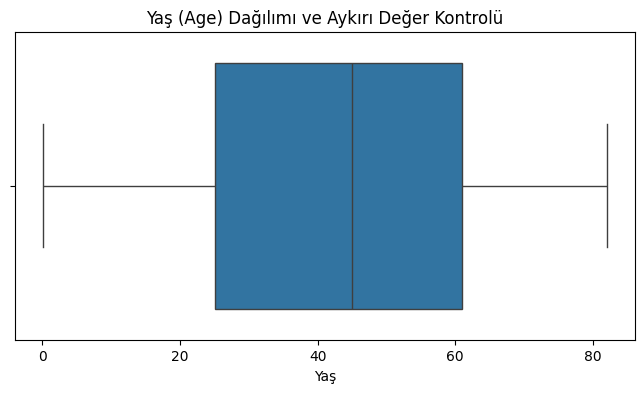

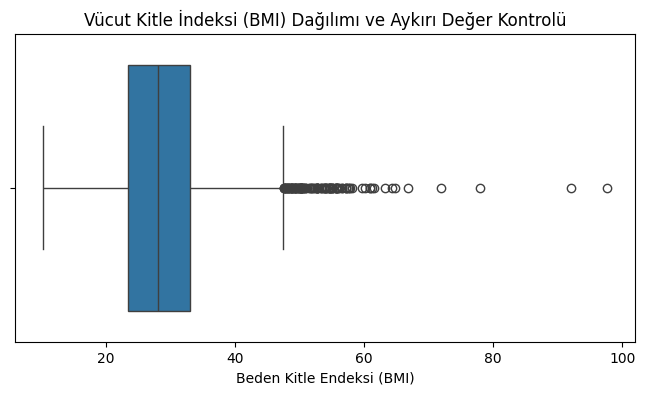

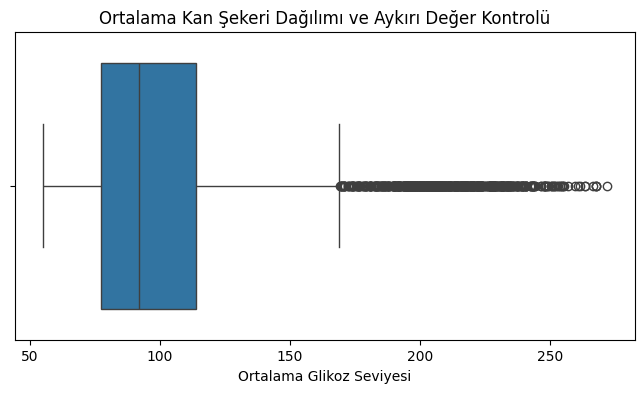

In [ ]:

# 1. Yaş (Age) için Boxplot
plt.figure(figsize=(8, 4))
#default grafik çok yüksek olduğu için boyutlarını düzenledim
sns.boxplot(x=df['age'])
plt.title('Yaş (Age) Dağılımı ve Aykırı Değer Kontrolü')
plt.xlabel('Yaş')
plt.show()

# 2. Vücut Kitle İndeksi (BMI) için Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['bmi'])
plt.title('Vücut Kitle İndeksi (BMI) Dağılımı ve Aykırı Değer Kontrolü')
plt.xlabel('Beden Kitle Endeksi (BMI)')
plt.show()

# 3. Ortalama Kan Şekeri (Avg Glucose Level) için Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['avg_glucose_level'])
plt.title('Ortalama Kan Şekeri Dağılımı ve Aykırı Değer Kontrolü')
plt.xlabel('Ortalama Glikoz Seviyesi')
plt.show()

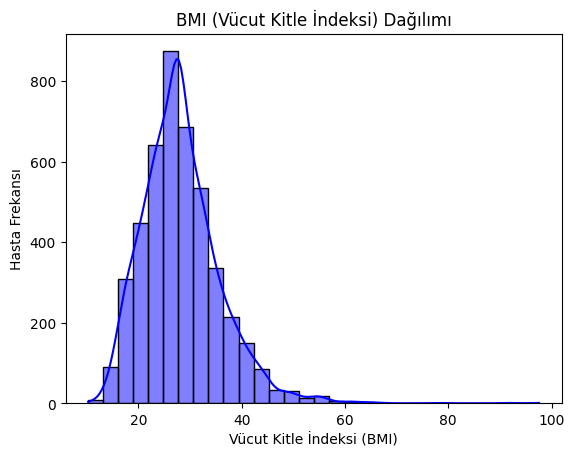

In [ ]:
# histogram, verisetindeki bmi dağılımı, normal dağılıma yakın
sns.histplot(data=df_temiz, x='bmi', kde=True, bins=30, color='blue')
plt.title('BMI (Vücut Kitle İndeksi) Dağılımı')
plt.xlabel('Vücut Kitle İndeksi (BMI)')
plt.ylabel('Hasta Frekansı')
plt.show()

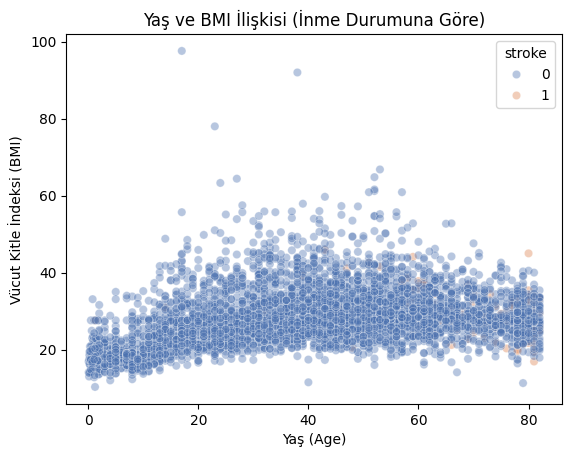

In [ ]:
# yaş-bmi scatterplot
sns.scatterplot(data=df_temiz, x='age', y='bmi', hue='stroke', palette='deep', alpha=0.4)
plt.title('Yaş ve BMI İlişkisi (İnme Durumuna Göre)')
plt.xlabel('Yaş (Age)')
plt.ylabel('Vücut Kitle İndeksi (BMI)')
plt.show()

In [ ]:
from scipy.stats import zscore


df_temiz2 = df[df['gender'] != 'Other'].copy()

# Nan değerleri görmezden gel
df_temiz2['bmi_zscore'] = zscore(df_temiz2['bmi'], nan_policy='omit')

# z skoru 3'ün dışında olan değerleri hesaplayıp, sütunda değerleri tutup filtreliyoruz
df_temiz3 = df_temiz2[(df_temiz2['bmi_zscore'] > -4) & (df_temiz2['bmi_zscore'] < 4)].copy()

# hesaplama için kullandığımız kolonu geri dropluyoruz
df_temiz3.drop('bmi_zscore', axis=1, inplace=True)

print("Satır sayısı (Orijinal):", df.shape[0])
print("Satır sayısı (BMI Z-Score Sonrası):", df_temiz3.shape[0])
print(f"Toplam {df.shape[0] - df_temiz3.shape[0]} BMI aykırı değeri Z-Score ile temizlendi.")

Satır sayısı (Orijinal): 5110
Satır sayısı (BMI Z-Score Sonrası): 4896
Toplam 214 BMI aykırı değeri Z-Score ile temizlendi.


In [ ]:
#NaN BMI->medyan
df_temiz3['bmi'] = df_temiz3['bmi'].fillna(df_temiz3['bmi'].median())

print("İşlem Sonrası df_temiz3 Eksik Değer Sayıları:\n", df_temiz3.isnull().sum())
orijinal_sayilar = df['stroke'].value_counts()
kalan_sayilar = df_temiz3['stroke'].value_counts()
silinen_sayilar = orijinal_sayilar - kalan_sayilar

print("Verisetindeki inme sayıları")
print(orijinal_sayilar)

print("Aykırı değerde silinen inme sayıları")
print(silinen_sayilar)

İşlem Sonrası df_temiz3 Eksik Değer Sayıları:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
Verisetindeki inme sayıları
stroke
0    4861
1     249
Name: count, dtype: int64
Aykırı değerde silinen inme sayıları
stroke
0    174
1     40
Name: count, dtype: int64


2.5.2  Seaborn ile Görselleştirme

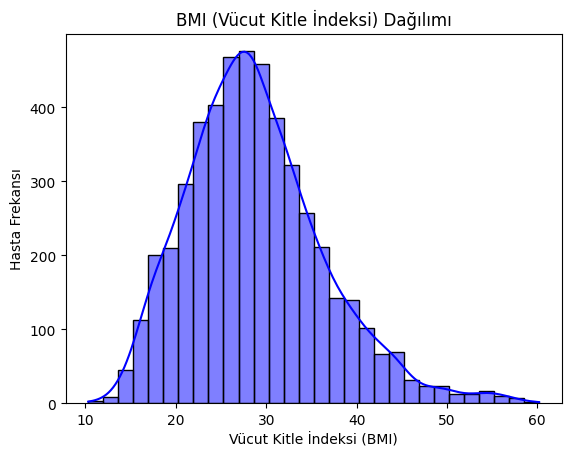

In [ ]:
# histogram, verisetindeki bmi dağılımı
sns.histplot(data=df_temiz3, x='bmi', kde=True, bins=30, color='blue')
plt.title('BMI (Vücut Kitle İndeksi) Dağılımı')
plt.xlabel('Vücut Kitle İndeksi (BMI)')
plt.ylabel('Hasta Frekansı')
plt.show()

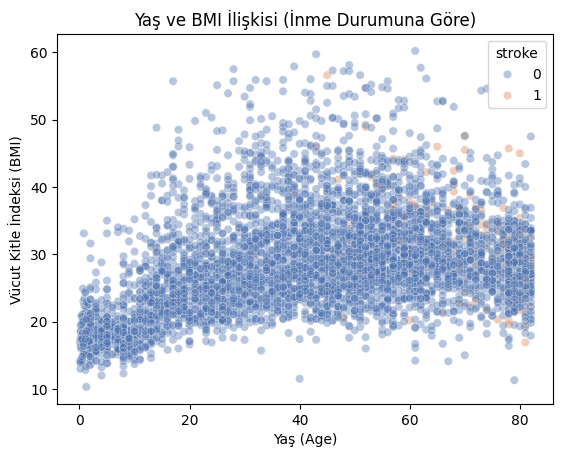

In [ ]:
# yaş-bmi scatterplot
sns.scatterplot(data=df_temiz3, x='age', y='bmi', hue='stroke', palette='deep', alpha=0.4)
plt.title('Yaş ve BMI İlişkisi (İnme Durumuna Göre)')
plt.xlabel('Yaş (Age)')
plt.ylabel('Vücut Kitle İndeksi (BMI)')
plt.show()

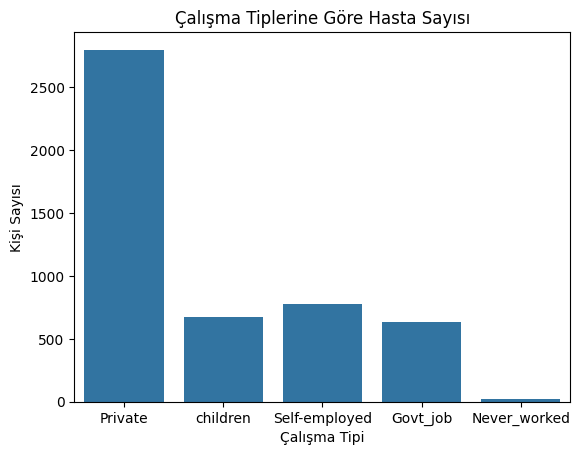

In [ ]:
# countplot- veri setindde çalışma dağılımı
sns.countplot(data=df_temiz3, x='work_type', order=df_temiz['work_type'].value_counts().index)
plt.title('Çalışma Tiplerine Göre Hasta Sayısı')
plt.xlabel('Çalışma Tipi')
plt.ylabel('Kişi Sayısı')
plt.show()

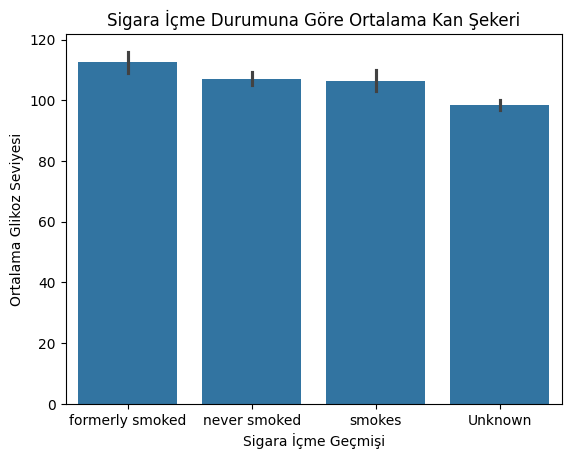

In [ ]:
# sigara içmeye göre kan şekeri sütun grafiği
sns.barplot(data=df_temiz3, x='smoking_status', y='avg_glucose_level')
plt.title('Sigara İçme Durumuna Göre Ortalama Kan Şekeri')
plt.xlabel('Sigara İçme Geçmişi')
plt.ylabel('Ortalama Glikoz Seviyesi')
plt.show()

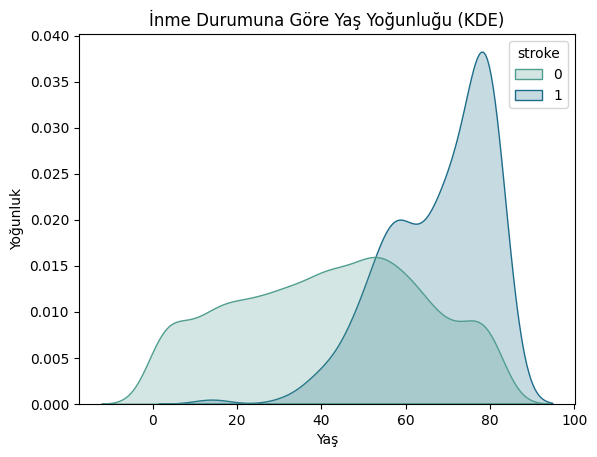

In [ ]:
# kde yaş-inme
sns.kdeplot(data=df_temiz3, x='age', hue='stroke', fill=True, common_norm=False, palette='crest')
plt.title('İnme Durumuna Göre Yaş Yoğunluğu (KDE)')
plt.xlabel('Yaş')
plt.ylabel('Yoğunluk')
plt.show()

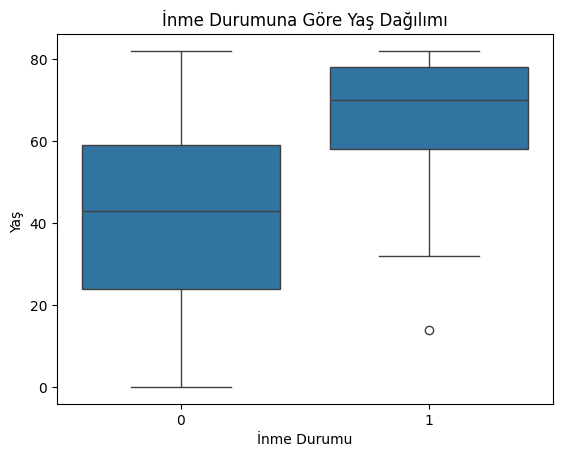

In [ ]:
# boxplot inme-yaş
sns.boxplot(data=df_temiz3, x='stroke', y='age')
plt.title('İnme Durumuna Göre Yaş Dağılımı')
plt.xlabel('İnme Durumu')
plt.ylabel('Yaş ')
plt.show()

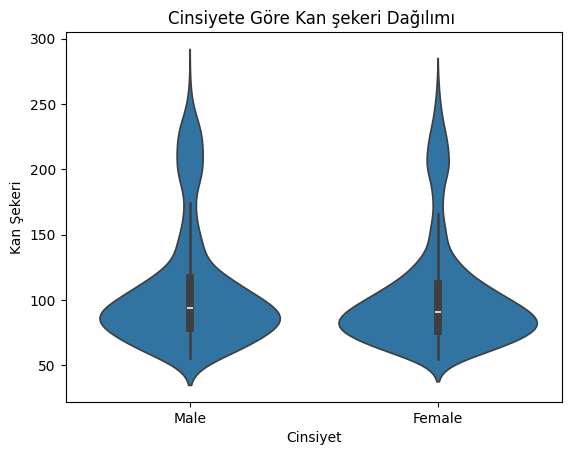

In [ ]:
#  violinplot Cinsiyete göre kan şekeri
sns.violinplot(data=df_temiz3, x='gender', y='avg_glucose_level')
plt.title('Cinsiyete Göre Kan şekeri Dağılımı ')
plt.xlabel('Cinsiyet')
plt.ylabel('Kan Şekeri')
plt.show()

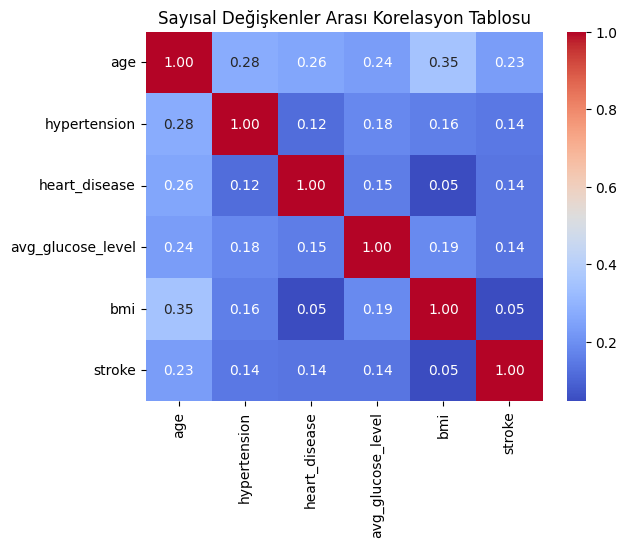

In [ ]:
#  heatmap: df_temiz3 korelasyonu
sns.heatmap(df_temiz3.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sayısal Değişkenler Arası Korelasyon Tablosu')
plt.show()


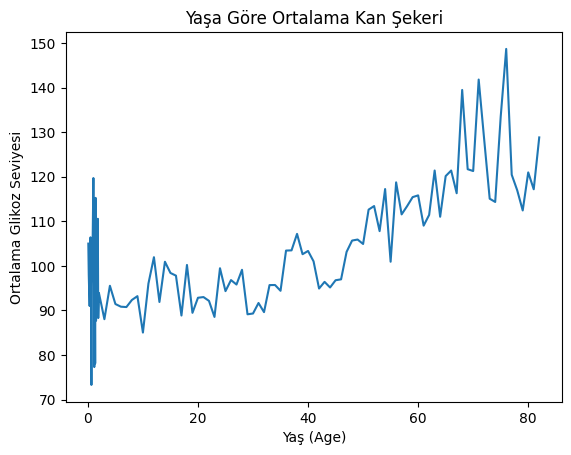

In [ ]:
# lineplot: Yaşa Göre Glikoz  (df_temiz3)
sns.lineplot(data=df_temiz3, x='age', y='avg_glucose_level',  errorbar=None)
plt.title('Yaşa Göre Ortalama Kan Şekeri')
plt.xlabel('Yaş (Age)')
plt.ylabel('Ortalama Glikoz Seviyesi')
plt.show()

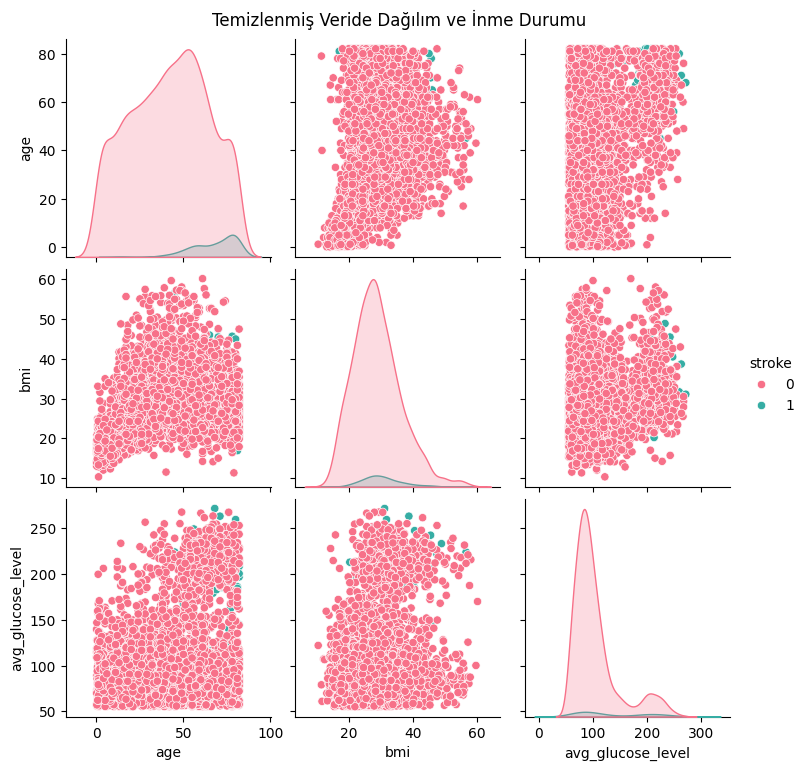

In [ ]:

#  pairplot: Genel dağılım
sns.pairplot(df_temiz3[['age', 'bmi', 'avg_glucose_level', 'stroke']], hue='stroke', palette='husl',)
plt.suptitle('Temizlenmiş Veride Dağılım ve İnme Durumu', y=1.02)
plt.show()


2.6 GROUPBY & KOŞULLU SORGULAR

In [ ]:
print("\n--- 2.6 GROUPBY & KOŞULLU SORGULAR ---")

# groupby + mean(): İnme durumuna göre yaş ortalaması
print("\n1. İnme Durumuna Göre Yaş Ortalaması:")
display(df_temiz3.groupby('stroke')['age'].mean())


--- 2.6 GROUPBY & KOŞULLU SORGULAR ---

1. İnme Durumuna Göre Yaş Ortalaması:


,age
stroke,
0,41.766614
1,67.712919


In [ ]:
# groupby + count(): Cinsiyete göre hasta sayısı
print("\n2. Cinsiyete Göre Hasta Sayısı:")
display(df_temiz3.groupby('gender')['bmi'].count())


2. Cinsiyete Göre Hasta Sayısı:


,bmi
gender,
Female,2889
Male,2007


In [ ]:
# groupby + agg(): Sigara içme durumuna göre glikoz seviyesi istatistikleri
print("\n3. Sigara Durumuna Göre Glikoz İstatistikleri:")
display(df_temiz3.groupby('smoking_status')['avg_glucose_level'].agg(['min', 'max', 'mean']))


3. Sigara Durumuna Göre Glikoz İstatistikleri:


,min,max,mean
smoking_status,,,
Unknown,55.23,254.60,98.371799
formerly smoked,55.27,267.76,112.543038
never smoked,55.12,267.60,107.161332
smokes,55.32,271.74,106.467561


In [ ]:
# groupby + sum(): Kalp hastalığı olan ve olmayanların toplam inme vakaları
print("\n4. Kalp Hastalığına Göre Toplam İnme Vakaları:")
display(df_temiz3.groupby('heart_disease')['stroke'].sum())



4. Kalp Hastalığına Göre Toplam İnme Vakaları:


,stroke
heart_disease,
0,169
1,40


In [ ]:
# groupby + std(): Çalışma tipine göre BMI standart sapması
print("\n5. Çalışma Tipine Göre BMI Standart Sapması:")
display(df_temiz3.groupby('work_type')['bmi'].std())



5. Çalışma Tipine Göre BMI Standart Sapması:


,bmi
work_type,
Govt_job,6.919375
Never_worked,7.441757
Private,7.116561
Self-employed,6.575210
children,4.540639


In [ ]:

#  loc[ koşul ]: Yaşı 60'tan büyük ve inme geçirmiş hastalar
print("\n6. Yaşı 60'tan Büyük ve İnme Geçirmiş İlk 5 Hasta:")
display(df_temiz3.loc[(df_temiz3['age'] > 60) & (df_temiz3['stroke'] == 1)].head())



6. Yaşı 60'tan Büyük ve İnme Geçirmiş İlk 5 Hasta:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1


In [ ]:
#  Kadın ve hipertansiyonu olan hastalar
print("\n7. Hipertansiyonu Olan Kadın Hastalar:")
display(df_temiz3.query("gender == 'Female' and hypertension == 1").head())


7. Hipertansiyonu Olan Kadın Hastalar:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
10,Female,81.0,1,0,Yes,Private,Rural,80.43,29.7,never smoked,1
15,Female,50.0,1,0,Yes,Self-employed,Rural,167.41,30.9,never smoked,1
21,Female,52.0,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1
32,Female,82.0,1,0,Yes,Self-employed,Urban,196.92,22.2,never smoked,1


In [ ]:

def check_average_age(group):
    return group['age'].mean() > 50

display(df_temiz3.groupby('work_type').filter(check_average_age).head())

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
11,Female,61.0,0,1,Yes,Govt_job,Rural,120.46,36.8,smokes,1
15,Female,50.0,1,0,Yes,Self-employed,Rural,167.41,30.9,never smoked,1
20,Female,71.0,0,0,Yes,Govt_job,Rural,193.94,22.4,smokes,1
21,Female,52.0,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1


In [ ]:
# groupby + transform(): Her cinsiyetin kendi BMI ortalamasını tüm satırlara yayma
df_temiz3['Gender_Avg_BMI'] = df_temiz3.groupby('gender')['bmi'].transform('mean')
print("\n9. Yeni Sütun Olarak Cinsiyet Bazlı BMI Ortalaması:")
display(df_temiz3[['gender', 'bmi', 'Gender_Avg_BMI']].head())


9. Yeni Sütun Olarak Cinsiyet Bazlı BMI Ortalaması:


,gender,bmi,Gender_Avg_BMI
0,Male,36.6,28.542451
2,Male,32.5,28.542451
3,Female,34.4,28.967255
4,Female,24.0,28.967255
5,Male,29.0,28.542451


In [ ]:
# sort_values + head(): En yüksek glikoz seviyesine sahip 10 hasta
print("\n10. En Yüksek Glikoz Seviyesine Sahip İlk 10 Hasta:")
display(df_temiz3.sort_values(by='avg_glucose_level', ascending=False).head(10))


10. En Yüksek Glikoz Seviyesine Sahip İlk 10 Hasta:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,Gender_Avg_BMI
193,Male,68.0,1,1,Yes,Private,Rural,271.74,31.1,smokes,1,28.542451
1207,Female,49.0,0,0,Yes,Private,Urban,267.76,29.3,formerly smoked,0,28.967255
3088,Female,76.0,0,0,Yes,Self-employed,Urban,267.61,27.9,smokes,0,28.967255
4983,Male,76.0,1,0,Yes,Private,Rural,267.60,30.5,never smoked,0,28.542451
2462,Female,60.0,0,0,No,Govt_job,Rural,266.59,25.5,never smoked,0,28.967255
3393,Female,67.0,1,0,Yes,Govt_job,Rural,263.56,26.3,never smoked,0,28.967255
135,Female,71.0,0,0,Yes,Govt_job,Urban,263.32,38.7,never smoked,1,28.967255
4457,Female,62.0,1,0,Yes,Self-employed,Rural,261.67,43.0,formerly smoked,0,28.967255
122,Male,80.0,0,0,Yes,Private,Rural,259.63,31.7,smokes,1,28.542451
4470,Male,28.0,0,0,No,Private,Urban,256.74,23.4,formerly smoked,0,28.542451
